In [1]:
from huggingface_hub import hf_hub_url, hf_hub_download
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split

REPO_ID = "julien-c/wine-quality"
data_path = hf_hub_download(repo_id=REPO_ID, filename="winequality-red.csv")

winedf = pd.read_csv(data_path, sep=";")


X = winedf.drop(["quality"], axis=1)
Y = winedf["quality"]

print(Y.value_counts())
print("👉🏽 Data labels are unbalanced")

X_train , X_test , Y_train , Y_test = train_test_split(X, Y, test_size=0.3, random_state=42, shuffle=True)


print(X.head())
print(Y_train.value_counts())
print("👉🏽 train dataset is unbalanced")




/Users/ozgeyavuz/490/tabular_data_classification/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64
👉🏽 Data labels are unbalanced
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.

In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Pipeline Tanımlama (Ölçeklendirme ve SVM)
# SVM performansının artırılması için StandardScaler kritik öneme sahiptir.
pipeline = Pipeline([
    ('scaler', StandardScaler()), # Veriyi Standartlaştır
    ('svm', svm.SVC())            # SVM modelini kullan
])

# 2. Denenecek Parametre Izgarası (Sadece 'rbf' ve ilgili hiperparametreler)
param_grid = {
    # Pipeline'daki 'svm' adımının parametrelerini hedefliyoruz:
    'svm__kernel': ['rbf'], # Sadece rbf çekirdeği sabitlenmiştir
    'svm__C': [1, 30, 70, 120], # Denenecek C değerleri (Ceza)
    'svm__gamma': [1, 0.5, 0.05, 0.005] # Denenecek gamma değerleri (Etki Alanı)
}

# 3. Grid Search Tanımlama ve Çalıştırma
# refit=True: En iyi parametrelerle en sonunda modeli yeniden eğit
# cv=5: 5 katlı çapraz doğrulama (Cross-Validation) kullan
grid = GridSearchCV(pipeline, param_grid, cv=5, refit=True, verbose=2)

# Grid Search'ü eğitim verisi üzerinde çalıştır
grid.fit(X_train, Y_train)

# 4. Sonuçları Görüntüleme
print("---------------------------------------")
print(f"🥇 En İyi Parametreler: {grid.best_params_}")
print(f"🎯 Çapraz Doğrulama En İyi Skoru: {grid.best_score_:.4f}")
print("---------------------------------------")

# En iyi model objesi
best_rbf_model = grid.best_estimator_

# Test seti üzerinde nihai performansı ölç
accuracy_tuned = best_rbf_model.score(X_test, Y_test)
print(f"Test Seti Doğruluğu (Tuned RBF): {accuracy_tuned*100:.2f}%")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END ............svm__C=1, svm__gamma=1, svm__kernel=rbf; total time=   0.0s
[CV] END ............svm__C=1, svm__gamma=1, svm__kernel=rbf; total time=   0.0s
[CV] END ............svm__C=1, svm__gamma=1, svm__kernel=rbf; total time=   0.0s
[CV] END ............svm__C=1, svm__gamma=1, svm__kernel=rbf; total time=   0.0s
[CV] END ............svm__C=1, svm__gamma=1, svm__kernel=rbf; total time=   0.0s
[CV] END ..........svm__C=1, svm__gamma=0.5, svm__kernel=rbf; total time=   0.0s
[CV] END ..........svm__C=1, svm__gamma=0.5, svm__kernel=rbf; total time=   0.0s
[CV] END ..........svm__C=1, svm__gamma=0.5, svm__kernel=rbf; total time=   0.0s
[CV] END ..........svm__C=1, svm__gamma=0.5, svm__kernel=rbf; total time=   0.0s
[CV] END ..........svm__C=1, svm__gamma=0.5, svm__kernel=rbf; total time=   0.0s
[CV] END .........svm__C=1, svm__gamma=0.05, svm__kernel=rbf; total time=   0.0s
[CV] END .........svm__C=1, svm__gamma=0.05, svm


--- Sınıflandırma Raporu (Optimize Edilmiş RBF) ---
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        17
           5       0.69      0.72      0.70       195
           6       0.60      0.67      0.64       200
           7       0.64      0.46      0.53        61
           8       0.33      0.17      0.22         6

    accuracy                           0.63       480
   macro avg       0.38      0.34      0.35       480
weighted avg       0.62      0.63      0.62       480



/Users/ozgeyavuz/490/tabular_data_classification/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ozgeyavuz/490/tabular_data_classification/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ozgeyavuz/490/tabular_data_classification/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beh

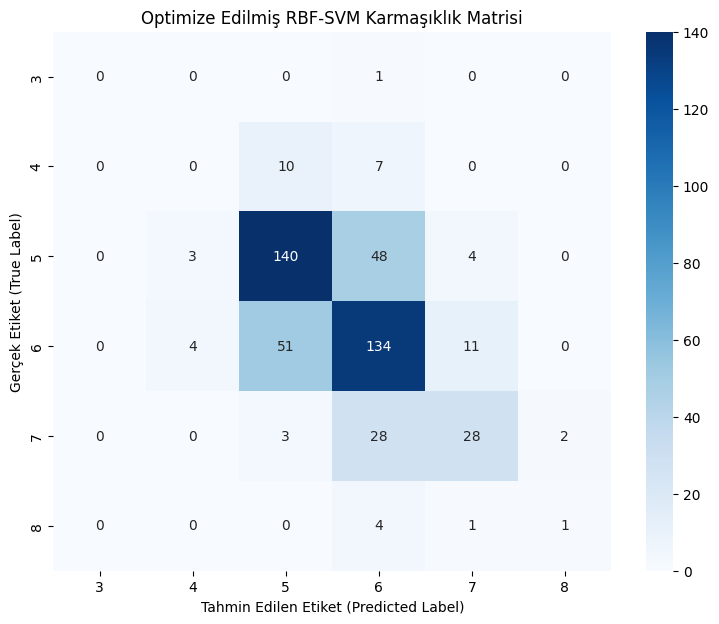

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Grid Search'ten gelen en iyi modeli kullan
best_rbf_model = grid.best_estimator_

# 1. Tahminleri Al
Y_pred = best_rbf_model.predict(X_test)

# 2. Sınıflandırma Raporunu Görüntüle (Opsiyonel ama faydalı)
print("\n--- Sınıflandırma Raporu (Optimize Edilmiş RBF) ---")
print(classification_report(Y_test, Y_pred))

# 3. Karmaşıklık Matrisini Hesapla
cm = confusion_matrix(Y_test, Y_pred)

# 4. Matrisi Görselleştir
plt.figure(figsize=(9, 7))

# Sınıf etiketlerini doğru almak için modelin sınıflarını kullanırız
class_labels = best_rbf_model.classes_ 

sns.heatmap(
    cm, 
    annot=True,              # Hücrelere sayıları yazdır
    fmt='d',                 # Sayıları tam sayı olarak biçimlendir
    cmap='Blues',            # Mavi renk skalası kullan
    xticklabels=class_labels, # X ekseni etiketleri
    yticklabels=class_labels  # Y ekseni etiketleri
)

plt.title('Optimize Edilmiş RBF-SVM Karmaşıklık Matrisi')
plt.ylabel('Gerçek Etiket (True Label)')
plt.xlabel('Tahmin Edilen Etiket (Predicted Label)')
plt.show()

In [4]:
import shap
import numpy as np
import shap
import numpy as np

model = best_rbf_model

# 1) Background'ı küçült 
background = shap.sample(X_train, 20, random_state=0).to_numpy()
X_test_np = X_test.to_numpy()

# 2) Modeli lambda ile kullan
f = lambda x: model.decision_function(x)

# 3) Kernel explainer
explainer = shap.KernelExplainer(f, background)

# 4) SHAP hesapla → hızlı!
shap_values = explainer.shap_values(X_test_np)


/Users/ozgeyavuz/490/tabular_data_classification/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
  0%|          | 0/480 [00:00<?, ?it/s]/Users/ozgeyavuz/490/tabular_data_classification/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/ozgeyavuz/490/tabular_data_classification/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/ozgeyavuz/490/tabular_data_classification/.venv/lib/python3.9/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/ozgeyavuz/490/tabular_data_classification/.ve

(480, 11, 6)
(480, 11)


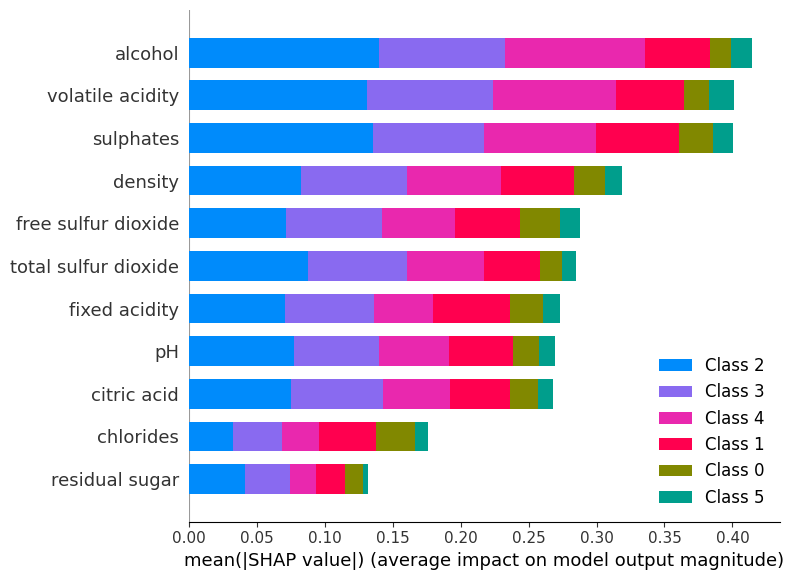

In [5]:
shap_array = np.array(shap_values)
print(shap_array.shape)
print(X_test_np.shape)
#mean_abs_shap = np.mean(np.abs(shap_array), axis=0)
# 5) Görselleştir
shap.summary_plot(shap_values,X_test,plot_type="bar",show=True)

[3 4 5 6 7 8]


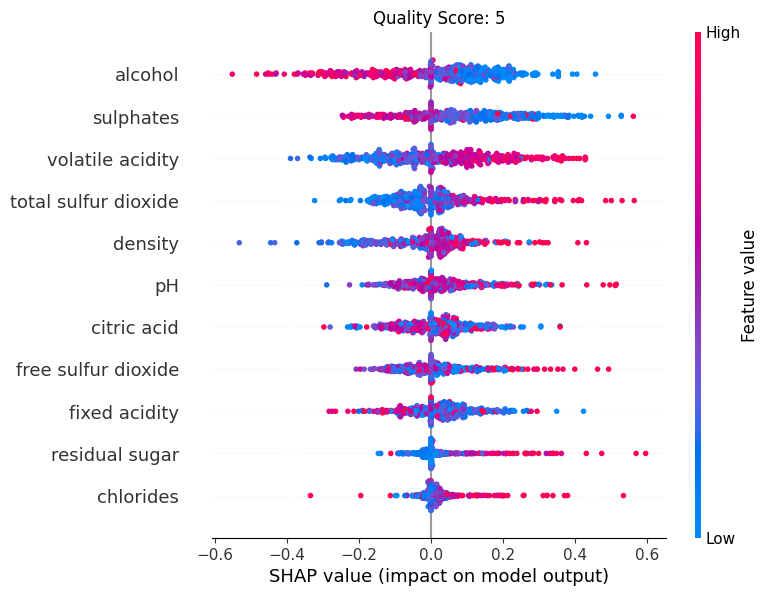

In [6]:
# print(shap_array[:,:,0].shape)
print(best_rbf_model.classes_)
encoding_map = {0:3, 1:4, 2:5, 3:6, 4:7, 5:8}  # örnek encoding map
class_index = 2 
class_label = best_rbf_model.classes_[class_index]
shap.summary_plot(shap_values[:, :, class_index], X_test, show=False)
plt.title(f"Quality Score: {class_label}")
plt.show()

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Örneğin, bir sınıf için SHAP değerleri:
class_index = 2
shap_matrix = shap_values[:, :, class_index]  # shape: (n_samples, n_features)

# Özellikler arası korelasyon matrisi (SHAP değerlerinin birlikte değişimi)
corr_matrix = np.corrcoef(shap_matrix, rowvar=False)  # shape: (n_features, n_features)

# DataFrame olarak isimlendirelim
feature_names = X_test.columns
corr_df = pd.DataFrame(corr_matrix, index=feature_names, columns=feature_names)

In [8]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import networkx as nx
# from scipy.stats import pearsonr

# # Örneğin, bir sınıf için SHAP değerleri:
# class_index = 2
# shap_matrix = shap_values[:, :, class_index]  # shape: (n_samples, n_features)

# feature_names = X_test.columns

# # 1. Ortalama mutlak SHAP değeri ile en iyi N feature'ı seç
# N = 3  # Kaç feature göstermek istiyorsun?
# mean_abs_shap = np.mean(np.abs(shap_matrix), axis=0)
# top_idx = np.argsort(mean_abs_shap)[::-1][:N]
# top_features = [feature_names[i] for i in top_idx]

# # 2. Sadece bu feature'ların SHAP değerleriyle korelasyon matrisi
# G = nx.Graph()
# for feat in top_features:
#     G.add_node(feat)

# all_corrs = []
# all_pvals = []
# for i, feat1 in enumerate(top_features):
#     for j, feat2 in enumerate(top_features):
#         if i < j:
#             idx1 = feature_names.get_loc(feat1)
#             idx2 = feature_names.get_loc(feat2)
#             x = shap_matrix[:, idx1]
#             y = shap_matrix[:, idx2]
#             corr, pval = pearsonr(x, y)
#             all_corrs.append(abs(corr))
#             all_pvals.append(pval)
#             G.add_edge(feat1, feat2, corr=corr, pval=pval)

# # 3. Genel skorlar
# overall_corr = np.mean(all_corrs) if all_corrs else 0
# mean_pval = np.mean(all_pvals) if all_pvals else 1
# scale = 20
# confidence = 1 - min(1, mean_pval * scale)

# # 4. Graph çizimi
# plt.figure(figsize=(8, 6))
# pos = nx.spring_layout(G, seed=42, k=2.5)
# weights = [G[u][v]['corr']*4 for u, v in G.edges()]
# nx.draw(
#     G, pos, with_labels=True, node_color='orange',
#     edge_color=weights, width=2.5, edge_cmap=plt.cm.coolwarm, edge_vmin=-1, edge_vmax=1
# )
# edge_labels = {
#     (u, v): f"corr={G[u][v]['corr']:.2f}\np={G[u][v]['pval']:.2g}"
#     for u, v in G.edges()
# }
# nx.draw_networkx_edge_labels(
#     G, pos, edge_labels=edge_labels, font_size=11, bbox=dict(alpha=0.7),
#     label_pos=0.7, rotate=False
# )

# plt.title(
#     f"Top {N} SHAP Features: Pairwise SHAP Correlations\n"
#     f"Overall mean abs corr: {overall_corr:.2f} | Confidence: {confidence:.2f}"
# )
# plt.tight_layout()
# plt.show()

In [9]:
# import networkx as nx
# # Sadece güçlü ilişkileri göstermek için 
# threshold = 0.3  # |korelasyon| > 0.3 olanlar

# G = nx.Graph()

# # Düğümleri ekle
# for feat in feature_names:
#     G.add_node(feat)

# # Kenarları ekle
# for i, feat1 in enumerate(feature_names):
#     for j, feat2 in enumerate(feature_names):
#         if i < j and abs(corr_df.iloc[i, j]) > threshold:
#             G.add_edge(feat1, feat2, weight=corr_df.iloc[i, j])

# # Graph çizimi
# plt.figure(figsize=(8, 6))
# pos = nx.spring_layout(G, seed=42)
# edges = G.edges()
# weights = [abs(G[u][v]['weight']) for u,v in edges]
# nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color=weights, width=2.0, edge_cmap=plt.cm.coolwarm)
# plt.title("Feature Interaction Graph (SHAP-based)")
# plt.show()

In [10]:
# import networkx as nx
# from scipy.stats import pearsonr

# threshold = 0.3  # |korelasyon| > 0.3 olanlar

# G = nx.Graph()

# # Düğümleri ekle
# for feat in feature_names:
#     G.add_node(feat)

# # Kenarları ekle: corr, confidence (|corr|) ve p-value
# for i, feat1 in enumerate(feature_names):
#     for j, feat2 in enumerate(feature_names):
#         if i < j:
#             x = shap_matrix[:, i]
#             y = shap_matrix[:, j]
#             corr, pval = pearsonr(x, y)
#             if abs(corr) > threshold:
#                 G.add_edge(
#                     feat1, feat2,
#                     corr=corr,
#                     confidence=abs(corr),
#                     p_value=pval
#                 )

# # Örnek: Kenar değerlerini yazdır
# for u, v, data in G.edges(data=True):
#     print(f"{u} - {v}: corr={data['corr']:.2f}, confidence={data['confidence']:.2f}, p-value={data['p_value']:.3g}")

# # Graph çizimi (isteğe bağlı)
# plt.figure(figsize=(10, 6))
# pos = nx.spring_layout(G, seed=42)
# edges = G.edges()
# weights = [data['confidence'] for _, _, data in G.edges(data=True)]
# nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color=weights, width=2.0, edge_cmap=plt.cm.coolwarm)
# plt.title("Feature Interaction Graph (SHAP-based)\n(Edge: corr, confidence, p-value)")
# plt.show()

In [11]:
# import networkx as nx
# from scipy.stats import pearsonr
# import matplotlib.pyplot as plt

# threshold = 0.3  # |korelasyon| > 0.3 olanlar

# G = nx.Graph()
# for feat in feature_names:
#     G.add_node(feat)

# for i, feat1 in enumerate(feature_names):
#     for j, feat2 in enumerate(feature_names):
#         if i < j:
#             x = shap_matrix[:, i]
#             y = shap_matrix[:, j]
#             corr, pval = pearsonr(x, y)
#             if abs(corr) > threshold:
#                 G.add_edge(
#                     feat1, feat2,
#                     corr=corr,
#                     confidence=abs(corr),
#                     p_value=pval
#                 )

# plt.figure(figsize=(12, 8))
# pos = nx.spring_layout(G, seed=42, k=3.5)  # k parametresi ile düğümler arası mesafe artırıldı

# edges = G.edges()
# weights = [data['confidence']*3 for _, _, data in G.edges(data=True)]  # kalınlık artırıldı
# nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color=weights, width=2.0, edge_cmap=plt.cm.coolwarm)

# # Kenar etiketlerini hazırla
# edge_labels = {
#     (u, v): f"corr={data['corr']:.2f}\np={data['p_value']:.2g}"
#     for u, v, data in G.edges(data=True)
# }
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, bbox=dict(alpha=0.7))

# plt.title("Feature Interaction Graph (SHAP-based)\n(Edge: corr, p-value)")
# plt.tight_layout()
# plt.show()

In [12]:
# # alcohol ve sulphates feature değerleri arasında korelasyon
# corr_feat, _ = pearsonr(X_test['alcohol'], X_test['sulphates'])
# print(f"Feature value corr: {corr_feat:.2f}")

# # alcohol ve sulphates SHAP değerleri arasında korelasyon
# idx_alc = feature_names.get_loc('alcohol')
# idx_sul = feature_names.get_loc('sulphates')
# corr_shap, _ = pearsonr(shap_matrix[:, idx_alc], shap_matrix[:, idx_sul])
# print(f"SHAP value corr: {corr_shap:.2f}")

In [18]:
# import networkx as nx
# import matplotlib.pyplot as plt
# from scipy.stats import pearsonr
# import numpy as np

# N = 4 # En iyi kaç feature göstermek istiyorsun?
# scale = 20  # p-value'yu confidence'a dönüştürmek için ölçek

# 1. En önemli N feature'ı bul (ortalama mutlak SHAP değeri ile)
# mean_abs_shap = np.abs(np.mean((shap_matrix), axis=0))
# top_idx = np.argsort(mean_abs_shap)[::-1][:N]
# top_features = [feature_names[i] for i in top_idx]

# # 2. Sadece bu feature'lar arasında edge oluştur
# G_top = nx.Graph()
# for feat in top_features:
#     G_top.add_node(feat)

# for i, feat1 in enumerate(top_features):
#     for j, feat2 in enumerate(top_features):
#         if i < j:
#             idx1 = feature_names.get_loc(feat1)
#             idx2 = feature_names.get_loc(feat2)
#             x = shap_matrix[:, idx1]
#             y = shap_matrix[:, idx2]
#             corr, pval = pearsonr(x, y)
#             # p-value'dan confidence score hesapla
#             confidence = 1 - min(1, pval * 100)
#             G_top.add_edge(
#                 feat1, feat2,
#                 corr=corr,
#                 confidence=confidence,
#                 p_value=pval
#             )

# # 3. Graph çizimi
# plt.figure(figsize=(9, 7))
# pos = nx.spring_layout(G_top, seed=42, k=1.5)
# weights = [data['corr']*4 for _, _, data in G_top.edges(data=True)]  # abs yok!
# nx.draw(
#     G_top, pos, with_labels=True, node_color='orange',
#     edge_color=weights, width=2.5, edge_cmap=plt.cm.coolwarm, edge_vmin=-1, edge_vmax=1
# )

# edge_labels = {
#     (u, v): f"corr={data['corr']:.2f}\np={data['p_value']:.2g}\nconf={data['confidence']:.2f}"
#     for u, v, data in G_top.edges(data=True)
# }
# nx.draw_networkx_edge_labels(G_top, pos, edge_labels=edge_labels, font_size=12, bbox=dict(alpha=0.7))

# from scipy.stats import pearsonr

# # Seçili feature'ların sonuç (Y) ile korelasyonlarının ortalaması
# target_corrs = []
# for feat in top_features:
#     x = X_test[feat]
#     y = Y_test
#     corr, _ = pearsonr(x, y)
#     target_corrs.append(abs(corr))
# overall_target_corr = np.mean(target_corrs) if target_corrs else 0

# plt.title(
#     f"Top {N} Features & Their Interactions\n"
#     f"(Confidence from p-value)\n"
#     f"Mean abs corr with target: {overall_target_corr:.2f}"
# )
# plt.tight_layout()
# plt.show()

In [ ]:
# from scipy.stats import pearsonr
# import numpy as np

# N = 2  # Kaç feature göstermek istiyorsun?

# # 1. Her bir feature'ın sonuçla korelasyonunu hesapla
# feature_corrs = []
# for feat in feature_names:
#     corr, pval = pearsonr(X_test[feat], Y_test)
#     feature_corrs.append({'feature': feat, 'corr': corr, 'pval': pval})

# # 2. En yüksek mutlak korelasyona sahip N feature'ı seç
# top_features = sorted(feature_corrs, key=lambda d: abs(d['corr']), reverse=True)[:N]

# print(f"Top {N} features with highest |corr(feature, target)|:")
# for f in top_features:
#     print(f"{f['feature']}: corr={f['corr']:.2f}, p={f['pval']:.2g}")

# # 3. Ortalama mutlak korelasyon ve ortalama p-value (confidence)
# mean_abs_corr = np.mean([abs(f['corr']) for f in top_features])
# mean_pval = np.mean([f['pval'] for f in top_features])
# scale = 20
# confidence = 1 - min(1, mean_pval * scale)

# print(f"\nMean abs corr with target: {mean_abs_corr:.2f}")
# print(f"Mean p-value: {mean_pval:.2g}")
# print(f"Confidence (from mean p-value): {confidence:.2f}")

Top 2 features with highest |corr(feature, target)|:
alcohol: corr=0.44, p=4.6e-24
volatile acidity: corr=-0.41, p=2e-20

Mean abs corr with target: 0.42
Mean p-value: 1e-20
Confidence (from mean p-value): 1.00


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_1788/609449336.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


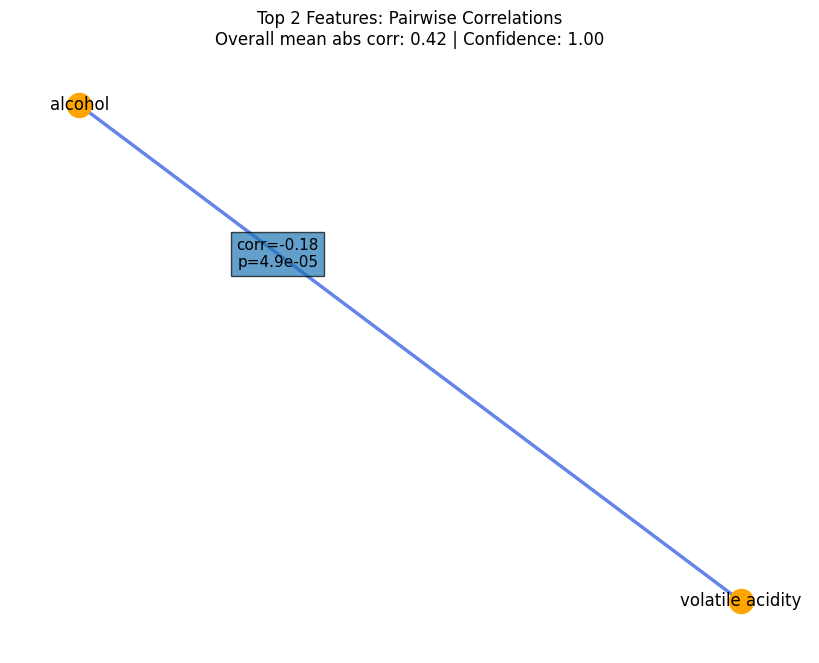

In [ ]:
# import networkx as nx
# import matplotlib.pyplot as plt

# # En iyi N feature'ın isimleri
# selected = [f['feature'] for f in top_features]

# # Graph oluştur
# G = nx.Graph()
# for feat in selected:
#     G.add_node(feat)

# all_corrs = []
# all_pvals = []
# for i, feat1 in enumerate(selected):
#     for j, feat2 in enumerate(selected):
#         if i < j:
#             x = X_test[feat1]
#             y = X_test[feat2]
#             corr, pval = pearsonr(x, y)
#             all_corrs.append(abs(corr))
#             all_pvals.append(pval)
#             G.add_edge(feat1, feat2, corr=corr, pval=pval)

# # 3. Ortalama mutlak korelasyon ve ortalama p-value (confidence)
# mean_abs_corr = np.mean([abs(f['corr']) for f in top_features])
# mean_pval = np.mean([f['pval'] for f in top_features])
# scale = 20
# confidence = 1 - min(1, mean_pval * scale)

# # Graph çizimi
# plt.figure(figsize=(8, 6))
# pos = nx.spring_layout(G, seed=42, k=2.5)
# weights = [G[u][v]['corr']*4 for u, v in G.edges()]
# nx.draw(
#     G, pos, with_labels=True, node_color='orange',
#     edge_color=weights, width=2.5, edge_cmap=plt.cm.coolwarm, edge_vmin=-1, edge_vmax=1
# )
# edge_labels = {
#     (u, v): f"corr={G[u][v]['corr']:.2f}\np={G[u][v]['pval']:.2g}"
#     for u, v in G.edges()
# }
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11, bbox=dict(alpha=0.7),label_pos=0.7,rotate=False)

# plt.title(
#     f"Top {N} Features: Pairwise Correlations\n"
#     f"Overall mean abs corr: {mean_abs_corr:.2f} | Confidence: {confidence:.2f}"
# )
# plt.tight_layout()
# plt.show()

-0.4055451439587876
0.4392914068344752
-0.035166485235617995
0.27339377479294236


/var/folders/z_/b7h4r8012hg406xrq_wqvw940000gn/T/ipykernel_1841/2154195255.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


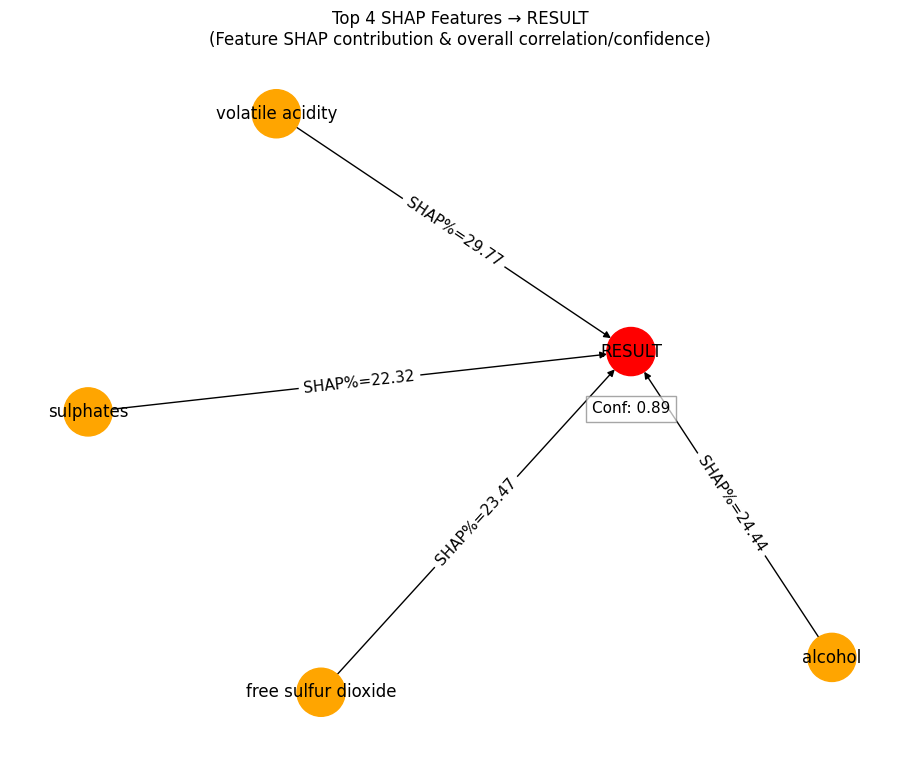

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import pearsonr

# SHAP değerlerine göre en iyi N feature
N = 4
class_index = 5
shap_matrix = shap_values[:, :, class_index]
feature_names = X_test.columns
mean_abs_shap = np.mean(np.abs(shap_matrix), axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:N]
top_features = [feature_names[i] for i in top_idx]
shap_contributions = mean_abs_shap[top_idx] / np.sum(mean_abs_shap[top_idx])


# Sonuç (target) ile korelasyon ve confidence hesapla
result_pvals = []
for feat in top_features:
    _, pval = pearsonr(X_test[feat], Y_test)
    print(_)
    result_pvals.append(pval)

mean_pval = np.mean(result_pvals)
scale = 1
confidence = 1 - min(1, mean_pval * scale)

# Graph: Featurelar ve Result node
G = nx.DiGraph()
for feat, shap_val in zip(top_features, shap_contributions):
    G.add_node(feat, shap=shap_val)
G.add_node("RESULT", color='red')

# Feature'dan RESULT'a: SHAP katkısı (probabilistic contribution)
for i, feat in enumerate(top_features):
    G.add_edge(feat, "RESULT", shap=shap_contributions[i])

# RESULT node'una: genel korelasyon ve confidence
G.nodes["RESULT"]['confidence'] = confidence

# Çizim
plt.figure(figsize=(9, 7))
pos = nx.spring_layout(G, seed=42)
node_colors = ['orange' if n != "RESULT" else 'red' for n in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=1200, font_size=12)

# Feature->RESULT kenarlarına SHAP katkısı yaz
edge_labels = {(u, v): f"SHAP%={G[u][v]['shap']*100:.2f}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11)

# RESULT node'una genel skorları yaz
x, y = pos["RESULT"]
plt.text(x, y-0.15, f"Conf: {confidence:.2f}", 
         ha='center', va='top', fontsize=11, bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

plt.title(f"Top {N} SHAP Features → RESULT\n(Feature SHAP contribution & overall correlation/confidence)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [25]:
print(Y.value_counts())
print("👉🏽 Data labels are unbalanced")

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64
👉🏽 Data labels are unbalanced
